In [8]:

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
matplotlib.rcdefaults()
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

In [9]:
# ═══════════════════════════════════════════════════
# DATA
# ═══════════════════════════════════════════════════
df = pd.read_excel('result_mcp.xlsx')


In [10]:

def classify(e):
    if pd.isna(e): return np.nan
    e = str(e).strip()
    if e == 'Pass': return 'Pass'
    elif 'Partial' in e: return 'Partial'
    return 'Fail'

df['Status'] = df['Error'].apply(classify)

Q_MAP = {
    'CML complete targets': 'CML\n(complete)',
    'CML top targets': 'CML\n(top)',
    'Top diseases treated with aspirin': 'Aspirin\n(top)',
    'All diseases treated with aspirin': 'Aspirin\n(all)',
    'Top diseases associated with TP53': 'TP53\n(top)',
    'All diseases associated with TP53': 'TP53\n(all)',
}
Q_SHORT = {k: v.replace('\n',' ') for k,v in Q_MAP.items()}
QUESTIONS = list(Q_MAP.keys())

def get_provider(m):
    if m in ['Haiku 3.5','Sonnet 4.5']: return 'Claude'
    elif m == 'biochirp': return 'BioChirp'
    return 'OpenAI'

df['Provider'] = df['Model'].apply(get_provider)
mcp_df = df[df['Model'] != 'biochirp'].copy()

BIOCHIRP = {
    'CML complete targets':4916, 'CML top targets':4916,
    'Top diseases treated with aspirin':363, 'All diseases treated with aspirin':363,
    'Top diseases associated with TP53':3258, 'All diseases associated with TP53':3258,
}
GPT = ['gpt-4.1-nano','gpt-4o-mini','gpt-4.1-mini','gpt-5-nano','gpt-5-mini']
CLAUDE = ['Haiku 3.5','Sonnet 4.5']
ALL_MCP = GPT + CLAUDE

def srate(sub):
    t = len(sub[sub['Status'].notna()])
    return (sub['Status']=='Pass').sum()/t*100 if t>0 else np.nan

# ═══════════════════════════════════════════════════
# STYLE — Nature soft palette, 7pt, white
# ═══════════════════════════════════════════════════
FS = 7

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans','Arial','Helvetica','DejaVu Sans'],
    'font.size': FS,
    'axes.titlesize': FS + 0.5,
    'axes.labelsize': FS,
    'xtick.labelsize': FS - 0.5,
    'ytick.labelsize': FS - 0.5,
    'legend.fontsize': FS - 1.5,
    'axes.linewidth': 0.35,
    'xtick.major.width': 0.35,
    'ytick.major.width': 0.35,
    'xtick.major.size': 2,
    'ytick.major.size': 2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'lines.linewidth': 0.6,
    'patch.linewidth': 0.25,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.03,
    'pdf.fonttype': 42,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'text.color': '#1a1a2e',
    'axes.labelcolor': '#1a1a2e',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#555555',
})

# Soft Nature palette
C_BC   = '#4caf50'   # soft green
C_CL   = '#5c9fd4'   # soft blue
C_OA   = '#e8935a'   # soft orange
C_FAIL = '#d47272'   # muted red
C_PART = '#c9b84a'   # muted olive
C_PASS = '#6abf7b'   # soft green
C_GY   = '#999999'
C_LG   = '#d5d5d5'
C_AGENT = '#c97a5a'  # warm terracotta for agentic
C_CHAT  = '#7aabd4'  # cool slate-blue for chatendpoint

# Soft model palette — warm oranges for GPT, cool blues for Claude
MC = {
    'gpt-4.1-nano':'#f4c49a', 'gpt-4o-mini':'#f0a86e', 'gpt-4.1-mini':'#de8a50',
    'gpt-5-nano':'#c46e3a', 'gpt-5-mini':'#9e5028',
    'Haiku 3.5':'#a3cbe5', 'Sonnet 4.5':'#5a9fd4', 'BioChirp':C_BC,
}

def plabel(ax, lbl, x=-0.13, y=1.08):
    ax.text(x, y, lbl, transform=ax.transAxes, fontsize=FS+2.5,
            fontweight='bold', va='top', ha='left', color='#1a1a2e')

# ═══════════════════════════════════════════════════
# A4 FIGURE: 210 × 297 mm
# ═══════════════════════════════════════════════════
A4W = 210/25.4
A4H = 297/25.4

fig = plt.figure(figsize=(A4W, A4H), facecolor='white')

# 4 rows × 2 cols; row 4 = heatmap full-width
outer = gridspec.GridSpec(4, 2, figure=fig,
    hspace=0.58, wspace=0.36,
    left=0.09, right=0.96, top=0.96, bottom=0.04,
    height_ratios=[1, 1, 1, 1.2])


# ──────────────────────────────────────────────
# (a) Success rate by model — horizontal bars
# ──────────────────────────────────────────────
ax_a = fig.add_subplot(outer[0, 0])
models_a = ALL_MCP + ['BioChirp']
rates_a, colors_a = [], []
for m in models_a:
    if m == 'BioChirp':
        rates_a.append(100.0); colors_a.append(C_BC)
    else:
        rates_a.append(srate(mcp_df[mcp_df['Model']==m]))
        colors_a.append(C_CL if m in CLAUDE else C_OA)

y_a = np.arange(len(models_a))
ax_a.barh(y_a, rates_a, height=0.6, color=colors_a, edgecolor='white', lw=0.2, zorder=3)
ax_a.set_yticks(y_a); ax_a.set_yticklabels(models_a)
ax_a.set_xlabel('Success rate (%)'); ax_a.set_xlim(0, 118)
ax_a.invert_yaxis()
ax_a.axvline(50, color=C_LG, lw=0.3, ls=':', zorder=1)

for i, v in enumerate(rates_a):
    if not np.isnan(v):
        w = 'bold' if models_a[i]=='BioChirp' else 'normal'
        c = '#1a1a2e' if v < 95 else '#2e7d32'
        ax_a.text(v+1.5, i, f'{v:.0f}%', va='center', fontsize=FS-1.5, fontweight=w, color=c)

# Bracket annotations
ax_a.axhline(4.5, color=C_LG, lw=0.35, ls=':', zorder=1)
ax_a.axhline(6.5, color=C_LG, lw=0.35, ls=':', zorder=1)
ax_a.text(108, 2, 'OpenAI', fontsize=FS-1.5, color=C_OA, ha='center', fontstyle='italic')
ax_a.text(108, 5.5, 'Claude', fontsize=FS-1.5, color=C_CL, ha='center', fontstyle='italic')
ax_a.text(108, 7, 'Ours', fontsize=FS-1.5, color=C_BC, ha='center', fontstyle='italic', fontweight='bold')

plabel(ax_a, 'a')
ax_a.set_title('Success rate across all queries', loc='left', pad=3, fontweight='semibold')


# ──────────────────────────────────────────────
# (b) Stacked outcome — MCP models + BioChirp
# ──────────────────────────────────────────────
ax_b = fig.add_subplot(outer[0, 1])
all_b = ALL_MCP + ['biochirp']
od = {'Pass':[], 'Partial':[], 'Fail':[]}
for m in all_b:
    sub = df[df['Model']==m]
    t = len(sub[sub['Status'].notna()])
    for s in ['Pass','Partial','Fail']:
        if m == 'biochirp':
            od[s].append(100.0 if s=='Pass' else 0.0)
        else:
            od[s].append((sub['Status']==s).sum()/t*100 if t>0 else 0)

x_b = np.arange(len(all_b))
bot = np.zeros(len(all_b))
cm = {'Pass':C_PASS, 'Partial':C_PART, 'Fail':C_FAIL}
for s in ['Pass','Partial','Fail']:
    ax_b.bar(x_b, od[s], 0.65, bottom=bot, color=cm[s], edgecolor='white', lw=0.15, label=s, zorder=3)
    bot += np.array(od[s])

labels_b = [m if m != 'biochirp' else 'BioChirp' for m in all_b]
ax_b.set_xticks(x_b); ax_b.set_xticklabels(labels_b, rotation=40, ha='right')
ax_b.set_ylabel('Proportion of runs (%)'); ax_b.set_ylim(0, 109)
ax_b.legend(frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5,1.02),
            handlelength=0.8, handletextpad=0.2, columnspacing=0.5)
ax_b.axvline(4.5, color=C_GY, lw=0.3, ls=':', zorder=2)
ax_b.axvline(6.5, color=C_GY, lw=0.3, ls=':', zorder=2)
ax_b.text(2, 105, 'OpenAI', ha='center', fontsize=FS-2, color=C_OA, fontstyle='italic')
ax_b.text(5.5, 105, 'Claude', ha='center', fontsize=FS-2, color=C_CL, fontstyle='italic')
ax_b.text(7, 105, 'BioChirp', ha='center', fontsize=FS-2, color=C_BC, fontstyle='italic', fontweight='bold')

plabel(ax_b, 'b')
ax_b.set_title('Run outcome distribution', loc='left', pad=3, fontweight='semibold')


# ──────────────────────────────────────────────
# (c) Provider success per query — with BioChirp
# ──────────────────────────────────────────────
ax_c = fig.add_subplot(outer[1, 0])
cr, oar = [], []
for q in QUESTIONS:
    cr.append(srate(mcp_df[(mcp_df['Provider']=='Claude')&(mcp_df['Question']==q)]))
    oar.append(srate(mcp_df[(mcp_df['Provider']=='OpenAI')&(mcp_df['Question']==q)]))

x_c = np.arange(len(QUESTIONS))
wc = 0.26
ax_c.bar(x_c - wc, oar, wc, color=C_OA, edgecolor='white', lw=0.15, label='OpenAI', zorder=3)
ax_c.bar(x_c, cr, wc, color=C_CL, edgecolor='white', lw=0.15, label='Claude', zorder=3)
ax_c.bar(x_c + wc, [100]*len(QUESTIONS), wc, color=C_BC, edgecolor='white', lw=0.15,
         label='BioChirp', zorder=3, alpha=0.75)

for vals, off in [(oar, -wc), (cr, 0)]:
    for i, v in enumerate(vals):
        if v > 0 and not np.isnan(v):
            ax_c.text(i+off+wc/2, v+2, f'{v:.0f}', ha='center', fontsize=FS-2.5, fontweight='bold', color='#333')

ax_c.set_xticks(x_c); ax_c.set_xticklabels([Q_MAP[q] for q in QUESTIONS])
ax_c.set_ylabel('Success rate (%)'); ax_c.set_ylim(0, 116)
ax_c.legend(frameon=False, ncol=3, fontsize=FS-1.5, loc='upper right',
            handlelength=0.7, handletextpad=0.2, columnspacing=0.4)

plabel(ax_c, 'c')
ax_c.set_title('Provider success rate per query', loc='left', pad=3, fontweight='semibold')


# ──────────────────────────────────────────────
# (d) Agentic vs ChatEndPoint — each model×endpoint as unique row
# ──────────────────────────────────────────────
ax_d = fig.add_subplot(outer[1, 1])

oai_df = mcp_df[(mcp_df['Provider']=='OpenAI') & (mcp_df['Type'].notna())].copy()

# Build list of (label, rate, endpoint_type) for each unique combo
combos = []
for m in GPT:
    for t in ['Agentic', 'ChatEndPoint']:
        sub = oai_df[(oai_df['Model']==m)&(oai_df['Type']==t)]
        r = srate(sub)
        tag = 'A' if t == 'Agentic' else 'C'
        combos.append((f'{m} ({tag})', r, t))

# Sort by success rate ascending (worst at top)
combos.sort(key=lambda x: (x[1] if not np.isnan(x[1]) else -1))

labels_d = [c[0] for c in combos]
rates_d = [c[1] for c in combos]
colors_d = [C_AGENT if c[2]=='Agentic' else C_CHAT for c in combos]

y_d = np.arange(len(combos))
ax_d.barh(y_d, rates_d, height=0.6, color=colors_d, edgecolor='white', lw=0.2, zorder=3)
ax_d.set_yticks(y_d); ax_d.set_yticklabels(labels_d, fontsize=FS-1.5)
ax_d.set_xlabel('Success rate (%)'); ax_d.set_xlim(0, 100)
ax_d.invert_yaxis()
ax_d.axvline(50, color=C_LG, lw=0.3, ls=':', zorder=1)

for i, v in enumerate(rates_d):
    if not np.isnan(v) and v > 0:
        ax_d.text(v+1.2, i, f'{v:.0f}%', va='center', fontsize=FS-2, fontweight='bold', color='#333')
    elif v == 0 or np.isnan(v):
        ax_d.text(1.5, i, '0%', va='center', fontsize=FS-2, color=C_FAIL)

# Legend
lh_d = [mpatches.Patch(fc=C_AGENT, label='Agentic (A)'),
        mpatches.Patch(fc=C_CHAT, label='ChatEndPoint (C)')]
ax_d.legend(handles=lh_d, frameon=False, fontsize=FS-1.5, loc='lower right',
            handlelength=0.8, handletextpad=0.25)

# Summary stats annotation
ax_d.annotate(
    'Agentic: 5 error types, median 36s\nChat: 3 error types, median 14s',
    xy=(0.97, 0.97), xycoords='axes fraction', fontsize=FS-2.5, color='#555',
    va='top', ha='right', linespacing=1.4,
    bbox=dict(boxstyle='round,pad=0.25', fc='#fdf6f0', ec='#ddd', lw=0.3, alpha=0.9))

plabel(ax_d, 'd')
ax_d.set_title('OpenAI: Agentic vs ChatEndPoint success', loc='left', pad=3, fontweight='semibold')


# ──────────────────────────────────────────────
# (e) Reproducibility scatter
# ──────────────────────────────────────────────
ax_e = fig.add_subplot(outer[2, 0])
ax_e.plot([0.3, 6000], [0.3, 6000], color=C_LG, lw=0.4, ls='--', zorder=1)

for m in ALL_MCP:
    xp, yp = [], []
    for q in QUESTIONS:
        r1 = mcp_df[(mcp_df['Model']==m)&(mcp_df['Question']==q)&(mcp_df['Run']==1)]
        r2 = mcp_df[(mcp_df['Model']==m)&(mcp_df['Question']==q)&(mcp_df['Run']==2)]
        if len(r1)>0 and len(r2)>0:
            c1 = r1['Count'].values[0] if pd.notna(r1['Count'].values[0]) else 0
            c2 = r2['Count'].values[0] if pd.notna(r2['Count'].values[0]) else 0
            xp.append(max(c1,0.4)); yp.append(max(c2,0.4))
    mk = 'o' if m in GPT else 's'
    ax_e.scatter(xp, yp, s=10, c=MC.get(m,C_GY), marker=mk,
                 edgecolors='white', lw=0.15, alpha=0.85, zorder=3, label=m)

bc_x = [BIOCHIRP[q] for q in QUESTIONS]
ax_e.scatter(bc_x, bc_x, s=24, c=C_BC, marker='D', edgecolors='white', lw=0.25, zorder=4, label='BioChirp')

ax_e.set_xscale('log'); ax_e.set_yscale('log')
ax_e.set_xlabel('Run 1 — records'); ax_e.set_ylabel('Run 2 — records')
ax_e.set_xlim(0.25, 8000); ax_e.set_ylim(0.25, 8000)
ax_e.set_aspect('equal')
ax_e.legend(frameon=False, fontsize=FS-2.5, loc='lower right', markerscale=0.7,
            handletextpad=0.1, labelspacing=0.2, ncol=2, columnspacing=0.3)

# Annotation for BioChirp
ax_e.annotate('BioChirp:\nperfect diagonal', xy=(4916, 4916), fontsize=FS-2,
              xytext=(100, 4500), color=C_BC, fontweight='bold',
              arrowprops=dict(arrowstyle='->', color=C_BC, lw=0.5),
              ha='left', va='top')

plabel(ax_e, 'e')
ax_e.set_title('Reproducibility: Run 1 vs Run 2', loc='left', pad=3, fontweight='semibold')


# ──────────────────────────────────────────────
# (f) Error types by provider
# ──────────────────────────────────────────────
ax_f = fig.add_subplot(outer[2, 1])

err_map = {}
for e in mcp_df[mcp_df['Status']=='Fail']['Error'].str.strip().dropna().unique():
    if 'Upstream' in str(e) and 'Availability' in str(e): err_map[e] = 'Upstream\nUnavailable'
    elif 'Upstream' in str(e): err_map[e] = 'Retrieval\nFailure'
    elif 'MaxTurns' in str(e): err_map[e] = 'MaxTurns\nExceeded'
    elif 'BadRequest' in str(e): err_map[e] = 'Context\nOverflow'
    elif 'Timeout' in str(e): err_map[e] = 'MCP\nTimeout'
    else: err_map[e] = 'Other'

errs = mcp_df[mcp_df['Status']=='Fail'].copy()
errs['EType'] = errs['Error'].str.strip().map(err_map)
ecp = errs.groupby(['Provider','EType']).size().unstack(fill_value=0)
eorder = ['Retrieval\nFailure','MaxTurns\nExceeded','Context\nOverflow','MCP\nTimeout','Upstream\nUnavailable','Other']
eorder = [e for e in eorder if e in ecp.columns]

x_f = np.arange(len(eorder)); wf = 0.33
for i, prov in enumerate(['OpenAI','Claude']):
    if prov in ecp.index:
        vals = [ecp.loc[prov,e] if e in ecp.columns else 0 for e in eorder]
    else:
        vals = [0]*len(eorder)
    c = C_OA if prov=='OpenAI' else C_CL
    bars = ax_f.bar(x_f + (-wf/2+i*wf), vals, wf*0.88, color=c, edgecolor='white', lw=0.15, label=prov, zorder=3)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax_f.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4, str(v),
                      ha='center', fontsize=FS-2, fontweight='bold', color='#333')

ax_f.set_xticks(x_f); ax_f.set_xticklabels(eorder, fontsize=FS-1.5)
ax_f.set_ylabel('Failed runs')
ax_f.legend(frameon=False, loc='upper right', fontsize=FS-1.5)
ax_f.annotate('BioChirp: 0 errors\nacross all runs', xy=(0.97, 0.68), xycoords='axes fraction',
              fontsize=FS-1.5, color='#2e7d32', fontweight='bold', ha='right',
              bbox=dict(boxstyle='round,pad=0.25', fc='#e8f5e9', ec=C_BC, lw=0.35, alpha=0.9))

plabel(ax_f, 'f')
ax_f.set_title('MCP failure modes by provider', loc='left', pad=3, fontweight='semibold')


# ──────────────────────────────────────────────
# Bottom row: (g) latency + (h) heatmap
# ──────────────────────────────────────────────
gs_bot = outer[3, :].subgridspec(1, 2, wspace=0.30, width_ratios=[0.42, 0.58])

# (g) Latency — per model×endpoint combo
ax_g = fig.add_subplot(gs_bot[0])

# Build combo latency data sorted same as panel d (by success rate)
combos_g = []
for m in GPT:
    for t in ['Agentic', 'ChatEndPoint']:
        sub = oai_df[(oai_df['Model']==m)&(oai_df['Type']==t)]
        r = srate(sub)
        lat = sub[sub['Latency'].notna()]['Latency'].values
        tag = 'A' if t == 'Agentic' else 'C'
        combos_g.append((f'{m} ({tag})', r, t, lat))

combos_g.sort(key=lambda x: (x[1] if not np.isnan(x[1]) else -1))

lat_data_g = [c[3] if len(c[3])>0 else [0] for c in combos_g]
lat_colors_g = [C_AGENT if c[2]=='Agentic' else C_CHAT for c in combos_g]
lat_labels_g = [c[0] for c in combos_g]

bp = ax_g.boxplot(lat_data_g, vert=False, patch_artist=True, widths=0.55,
    medianprops=dict(color='#333', lw=0.6),
    whiskerprops=dict(lw=0.35, color='#666'),
    capprops=dict(lw=0.35, color='#666'),
    flierprops=dict(marker='.', ms=1.5, mfc=C_GY, mew=0.1), zorder=3)

for patch, c in zip(bp['boxes'], lat_colors_g):
    patch.set_facecolor(c); patch.set_alpha(0.55); patch.set_edgecolor('white'); patch.set_linewidth(0.2)

ax_g.set_yticklabels(lat_labels_g, fontsize=FS-1.5)
ax_g.set_xlabel('Latency (seconds)')
ax_g.invert_yaxis()

lh = [mpatches.Patch(fc=C_AGENT, alpha=0.55, label='Agentic'),
      mpatches.Patch(fc=C_CHAT, alpha=0.55, label='ChatEndPoint')]
ax_g.legend(handles=lh, frameon=False, loc='lower right', fontsize=FS-2)

plabel(ax_g, 'g')
ax_g.set_title('Latency: Agentic vs Chat', loc='left', pad=3, fontweight='semibold')


# ──────────────────────────────────────────────
# (h) Heatmap
# ──────────────────────────────────────────────
ax_h = fig.add_subplot(gs_bot[1])

hm_models = ALL_MCP + ['BioChirp']
matrix = np.full((len(QUESTIONS), len(hm_models)), np.nan)
annot = np.empty((len(QUESTIONS), len(hm_models)), dtype=object)

for j, m in enumerate(hm_models):
    for i, q in enumerate(QUESTIONS):
        if m == 'BioChirp':
            matrix[i,j] = BIOCHIRP[q]; annot[i,j] = f'{BIOCHIRP[q]:,}'
        else:
            sub = mcp_df[(mcp_df['Model']==m)&(mcp_df['Question']==q)]
            passes = sub[sub['Status']=='Pass']
            partials = sub[sub['Status']=='Partial']
            if len(passes) > 0:
                best = passes['Count'].max(); matrix[i,j] = best; annot[i,j] = f'{int(best)}'
            elif len(partials) > 0:
                matrix[i,j] = 0.5; annot[i,j] = '~1'
            else:
                matrix[i,j] = 0; annot[i,j] = '✗'

log_m = np.log10(matrix + 1)
log_max = np.log10(max(BIOCHIRP.values()) + 1)

# Soft diverging colormap: rose → cream → sage → forest
cmap = LinearSegmentedColormap.from_list('soft', [
    (0.00, '#f2dede'),   # soft rose (fail)
    (0.001, '#f2dede'),
    (0.015, '#fef9e7'),  # warm cream
    (0.06, '#d5ecd4'),   # light sage
    (0.20, '#a3d9a5'),   # medium sage
    (0.50, '#5cb85c'),   # balanced green
    (1.00, '#1b5e20'),   # deep forest
])

im = ax_h.imshow(log_m / log_max, cmap=cmap, aspect='auto', vmin=0, vmax=1)

for i in range(len(QUESTIONS)):
    for j in range(len(hm_models)):
        txt = annot[i,j]
        brightness = log_m[i,j] / log_max
        color = 'white' if brightness > 0.42 else '#333333'
        if txt == '✗': color = '#c0392b'
        w = 'bold' if hm_models[j] == 'BioChirp' else 'normal'
        fs = FS - 1.5 if hm_models[j] != 'BioChirp' else FS - 0.5
        ax_h.text(j, i, txt, ha='center', va='center', fontsize=fs, color=color, fontweight=w)

ax_h.set_xticks(np.arange(len(hm_models)))
ax_h.set_xticklabels(hm_models, rotation=40, ha='right', fontsize=FS-1)
ax_h.set_yticks(np.arange(len(QUESTIONS)))
ax_h.set_yticklabels([Q_SHORT[q] for q in QUESTIONS], fontsize=FS-0.5)

# Provider dividers
ax_h.axvline(4.5, color='white', lw=1.5)
ax_h.axvline(6.5, color='white', lw=1.5)

ax_h.text(2, -0.7, 'OpenAI', ha='center', fontsize=FS-0.5, color=C_OA, fontweight='bold')
ax_h.text(5.5, -0.7, 'Claude', ha='center', fontsize=FS-0.5, color=C_CL, fontweight='bold')
ax_h.text(7, -0.7, 'BioChirp', ha='center', fontsize=FS-0.5, color=C_BC, fontweight='bold')

plabel(ax_h, 'h', x=-0.07)
ax_h.set_title('Best records retrieved  (✗ = all runs failed)', loc='left', pad=12, fontweight='semibold')

# ═══════════════════════════════════════════════════
# SAVE
# ═══════════════════════════════════════════════════
fig.savefig('BioChirp_vs_MCP_A4.png', dpi=300, facecolor='white')
fig.savefig('BioChirp_vs_MCP_A4.pdf', dpi=300, facecolor='white')
print("✓ Saved BioChirp_vs_MCP_A4.png and .pdf")

✓ Saved BioChirp_vs_MCP_A4.png and .pdf


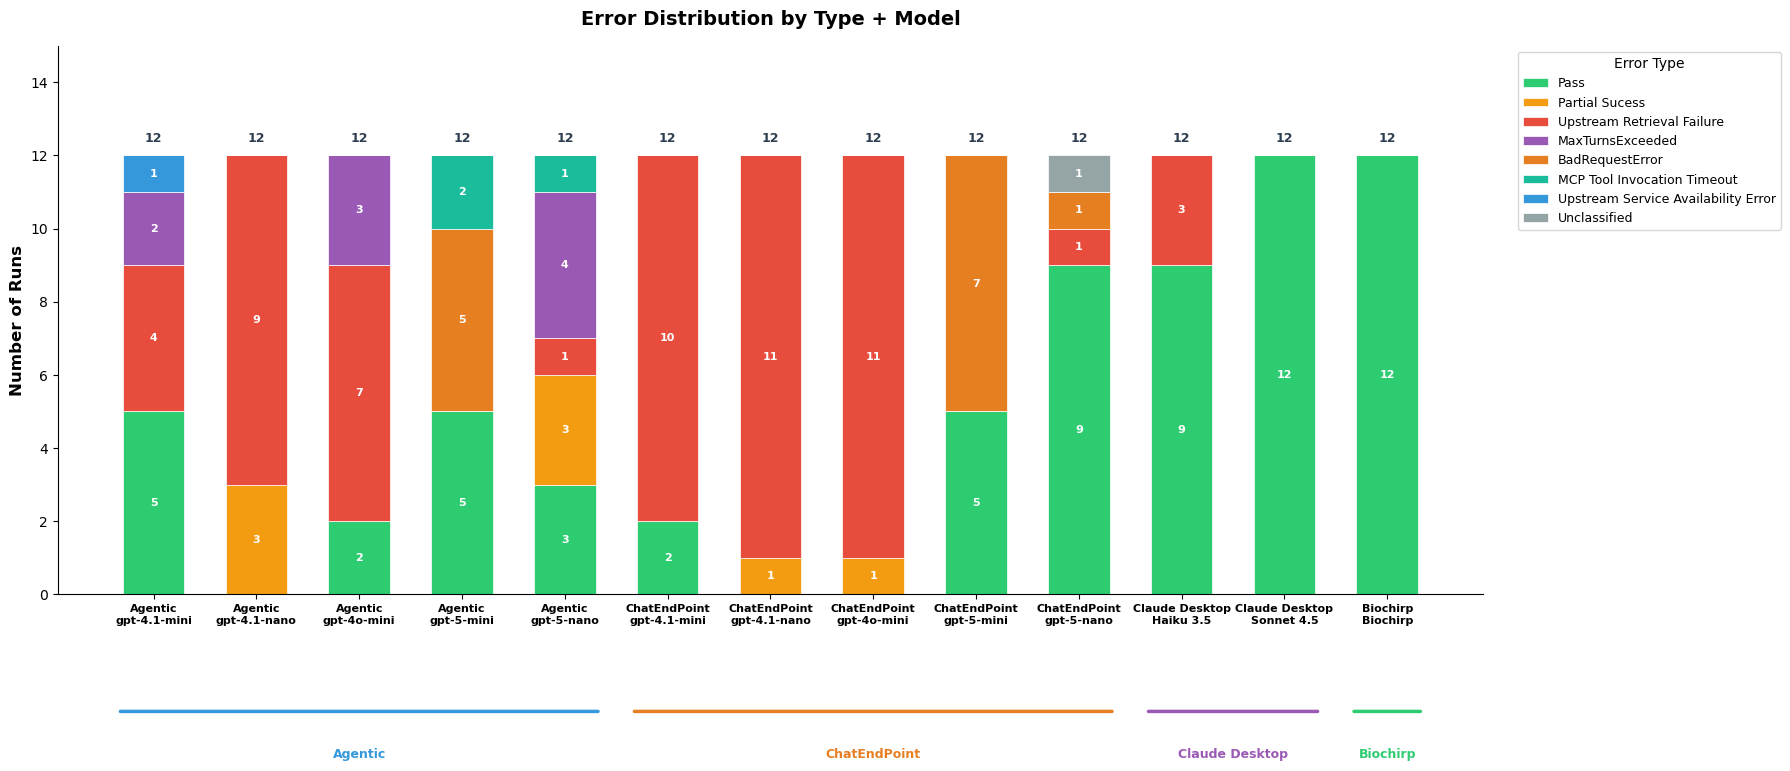

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_excel('result_mcp.xlsx')
df['Error'] = df['Error'].str.strip()

# Create X label = Type + Model
df['X_Label'] = df['Type'] + '\n' + df['Model']

# Get all unique x-labels in a logical order (group by Type)
type_order = ['Agentic', 'ChatEndPoint', 'Claude Desktop', 'Biochirp']
ordered_labels = []
for t in type_order:
    models = df[df['Type'] == t]['Model'].unique()
    for m in sorted(models):
        ordered_labels.append(f"{t}\n{m}")

# Define error types and their colors
all_errors = ['Pass', 'Partial Sucess', 'Upstream Retrieval Failure',
              'MaxTurnsExceeded', 'BadRequestError', 'MCP Tool Invocation Timeout',
              'Upstream Service Availability Error', 'Unclassified']
all_errors = [e for e in all_errors if e in df['Error'].values]

color_map = {
    'Pass': '#2ecc71',
    'Partial Sucess': '#f39c12',
    'Upstream Retrieval Failure': '#e74c3c',
    'MaxTurnsExceeded': '#9b59b6',
    'BadRequestError': '#e67e22',
    'MCP Tool Invocation Timeout': '#1abc9c',
    'Upstream Service Availability Error': '#3498db',
    'Unclassified': '#95a5a6',
}

# Count errors per x-label
data = {}
for label in ordered_labels:
    grp = df[df['X_Label'] == label]
    counts = grp['Error'].value_counts()
    data[label] = {err: counts.get(err, 0) for err in all_errors}

# Build stacked bar chart
fig, ax = plt.subplots(figsize=(18, 8))

x = np.arange(len(ordered_labels))
bar_width = 0.6
bottoms = np.zeros(len(ordered_labels))

for error in all_errors:
    values = [data[label][error] for label in ordered_labels]
    ax.bar(x, values, bar_width, bottom=bottoms, label=error,
           color=color_map.get(error, '#bdc3c7'), edgecolor='white', linewidth=0.5)

    # Add segment value labels
    for i, (v, b) in enumerate(zip(values, bottoms)):
        if v > 0:
            ax.text(x[i], b + v / 2, str(int(v)), ha='center', va='center',
                    fontsize=8, fontweight='bold', color='white')
    bottoms += np.array(values)

# Add total on top of each bar
for i, total in enumerate(bottoms):
    ax.text(x[i], total + 0.3, str(int(total)), ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#2c3e50')

# X-axis labels
ax.set_xticks(x)
ax.set_xticklabels(ordered_labels, fontsize=8, fontweight='bold', ha='center')

# Add colored brackets for type groups
type_ranges = {}
for i, label in enumerate(ordered_labels):
    t = label.split('\n')[0]
    if t not in type_ranges:
        type_ranges[t] = [i, i]
    else:
        type_ranges[t][1] = i

type_colors = {
    'Agentic': '#3498db',
    'ChatEndPoint': '#e67e22',
    'Claude Desktop': '#9b59b6',
    'Biochirp': '#2ecc71'
}
for t, (start, end) in type_ranges.items():
    mid = (start + end) / 2
    ax.annotate('', xy=(start - 0.35, -3.2), xytext=(end + 0.35, -3.2),
                arrowprops=dict(arrowstyle='-', color=type_colors.get(t, '#333'), lw=2.5),
                annotation_clip=False)
    ax.text(mid, -4.2, t, ha='center', va='top', fontsize=9, fontweight='bold',
            color=type_colors.get(t, '#333'))

# Styling
ax.set_ylabel('Number of Runs', fontsize=12, fontweight='bold')
ax.set_title('Error Distribution by Type + Model', fontsize=14, fontweight='bold', pad=15)
ax.legend(title='Error Type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, title_fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, max(bottoms) + 3)

plt.tight_layout()
plt.savefig('stacked_bar_type_model.png', dpi=200, bbox_inches='tight')
plt.show()
# print("Done!")